Timestep: 0.010, Acceptance Rate: 0.998
Timestep: 0.040, Acceptance Rate: 0.981
Timestep: 0.071, Acceptance Rate: 0.962
Timestep: 0.101, Acceptance Rate: 0.943
Timestep: 0.132, Acceptance Rate: 0.913
Timestep: 0.162, Acceptance Rate: 0.896
Timestep: 0.192, Acceptance Rate: 0.865
Timestep: 0.223, Acceptance Rate: 0.842
Timestep: 0.253, Acceptance Rate: 0.827
Timestep: 0.284, Acceptance Rate: 0.800
Timestep: 0.314, Acceptance Rate: 0.772
Timestep: 0.344, Acceptance Rate: 0.752
Timestep: 0.375, Acceptance Rate: 0.722
Timestep: 0.405, Acceptance Rate: 0.712
Timestep: 0.436, Acceptance Rate: 0.690
Timestep: 0.466, Acceptance Rate: 0.661
Timestep: 0.497, Acceptance Rate: 0.654
Timestep: 0.527, Acceptance Rate: 0.628
Timestep: 0.557, Acceptance Rate: 0.618
Timestep: 0.588, Acceptance Rate: 0.589
Timestep: 0.618, Acceptance Rate: 0.582
Timestep: 0.649, Acceptance Rate: 0.540
Timestep: 0.679, Acceptance Rate: 0.527
Timestep: 0.709, Acceptance Rate: 0.506
Timestep: 0.740, Acceptance Rate: 0.510


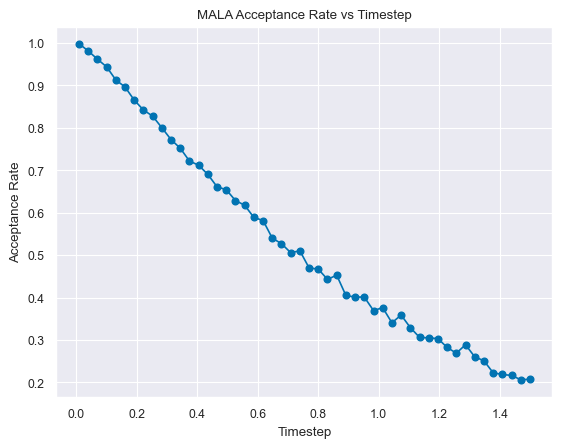

Stepsize: 0.010, Acceptance Rate: 0.991
Stepsize: 0.040, Acceptance Rate: 0.957
Stepsize: 0.071, Acceptance Rate: 0.928
Stepsize: 0.101, Acceptance Rate: 0.902
Stepsize: 0.132, Acceptance Rate: 0.859
Stepsize: 0.162, Acceptance Rate: 0.840
Stepsize: 0.192, Acceptance Rate: 0.805
Stepsize: 0.223, Acceptance Rate: 0.773
Stepsize: 0.253, Acceptance Rate: 0.764
Stepsize: 0.284, Acceptance Rate: 0.729
Stepsize: 0.314, Acceptance Rate: 0.696
Stepsize: 0.344, Acceptance Rate: 0.674
Stepsize: 0.375, Acceptance Rate: 0.651
Stepsize: 0.405, Acceptance Rate: 0.629
Stepsize: 0.436, Acceptance Rate: 0.600
Stepsize: 0.466, Acceptance Rate: 0.565
Stepsize: 0.497, Acceptance Rate: 0.557
Stepsize: 0.527, Acceptance Rate: 0.529
Stepsize: 0.557, Acceptance Rate: 0.508
Stepsize: 0.588, Acceptance Rate: 0.503
Stepsize: 0.618, Acceptance Rate: 0.477
Stepsize: 0.649, Acceptance Rate: 0.457
Stepsize: 0.679, Acceptance Rate: 0.431
Stepsize: 0.709, Acceptance Rate: 0.407
Stepsize: 0.740, Acceptance Rate: 0.404


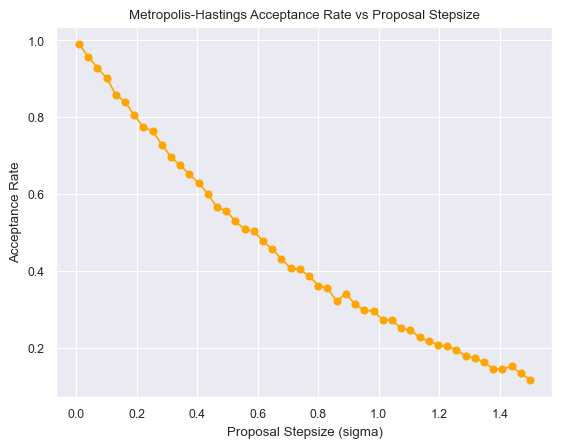

In [ ]:
import numpy as np
import seaborn as sns
from modules.function_sampling import metropolis_hastings, MALA, stochasticMALA
from modules.helpers import harmonic_oscillator_helpers as hlp, get_acf
from hydrogen_molecule import h2_wavefunction
import matplotlib.pyplot as plt
sns.set_style('darkgrid')
sns.set_context('paper')
sns.set_palette("colorblind")


def optimise_step_H2():
    q1 = np.array([0, 0, 1])
    q2 = np.array([0, 0, -1])
    theta_init = np.array([1., 1., 1.])
    wf = h2_wavefunction(thetas=theta_init, q1=q1, q2=q2)

    def wavefunction_wrapper_MALA(coords):
        coords = np.asarray(coords)
        r1, r2 = coords[:, 0:3], coords[:, 3:6]
        return wf.psi(r1, r2)

    def f_prime_MALA(coords):
        from modules.differentiators import central_difference
        coords = np.asarray(coords)
        grad = central_difference(
            wavefunction_wrapper_MALA, coords, h=[1e-4]*6, order=2)
        return np.sum(grad, axis=0)

    timesteps = np.linspace(0.01, 1.5, 50)
    acceptance_MALA = []

    for t in timesteps:
        _, acceptance_rate_MALA = MALA(f=wavefunction_wrapper_MALA, f_prime=f_prime_MALA, x_0=[
            1., 1., 1., -1., -1., -1.], timestep=t, xmin=[-10.]*6, xmax=[10.]*6, N=10000, detail=False, return_acceptance=True)

        acceptance_MALA.append(acceptance_rate_MALA)
        print(
            f"Timestep: {t:.3f}, Acceptance Rate: {acceptance_rate_MALA:.3f}")

    plt.plot(timesteps, acceptance_MALA, marker='o')
    plt.xlabel("Timestep")
    plt.ylabel("Acceptance Rate")
    plt.title("MALA Acceptance Rate vs Timestep")
    plt.grid(True)
    plt.show()

    def wavefunction_wrapper_MH(coords):
        coords = np.asarray(coords)
        r1, r2 = coords[:, 0:3], coords[:, 3:6]
        return wf.probability_density(r1, r2)

    stepsize = np.linspace(0.01, 1.5, 50)
    acceptance_MH = []

    for s in stepsize:
        _, acceptance_rate_MH = metropolis_hastings(f=wavefunction_wrapper_MH, f_prop='gaussian', x_0=np.ones(
            6, dtype=float), xmax=[10.]*6, xmin=[-10.]*6, N=10000, kwrgs={'sigma': s}, detail=False, return_acceptance=True)
        acceptance_MH.append(acceptance_rate_MH)
        print(f"Stepsize: {s:.3f}, Acceptance Rate: {acceptance_rate_MH:.3f}")

    plt.plot(stepsize, acceptance_MH, marker='o', color='orange')
    plt.xlabel("Proposal Stepsize (sigma)")
    plt.ylabel("Acceptance Rate")
    plt.title("Metropolis-Hastings Acceptance Rate vs Proposal Stepsize")
    plt.grid(True)
    plt.show()


def test_thinning():
    q1 = np.array([0, 0, 1])
    q2 = np.array([0, 0, -1])
    theta = np.array([1., 1., 1.])
    wf = h2_wavefunction(thetas=theta, q1=q1, q2=q2)

    N_samples = 100000
    r_0 = [1.] * 6
    thinning = 20

    def wavefunction_wrapper(coords):
        coords = np.asarray(coords)
        r1, r2 = coords[:, 0:3], coords[:, 3:6]
        return wf.probability_density(r1, r2)

    samples_no_thin = metropolis_hastings(f=wavefunction_wrapper, f_prop='gaussian', x_0=r_0, xmin=[
        -10.]*6, xmax=[10.]*6, N=N_samples, kwrgs={'sigma': 0.8}, detail=True, thinning=1)

    samples_thin = metropolis_hastings(f=wavefunction_wrapper, f_prop='gaussian', x_0=r_0, xmin=[
        -10.]*6, xmax=[10.]*6, N=N_samples, kwrgs={'sigma': 0.8}, detail=True, thinning=thinning)

    max_lag = 1000
    ac_no_thin = get_acf(samples_no_thin, max_lag=max_lag)
    ac_thin = get_acf(samples_thin, max_lag=max_lag)

    tau_no_thin = np.where(ac_no_thin < 1/np.e)[0][0]
    tau_thin = np.where(ac_thin < 1/np.e)[0][0]

    print(f"Correlation time without thinning: {tau_no_thin} steps")
    print(f"Correlation time with thinning: {tau_thin} steps")

    ess_no_thin = len(samples_no_thin) / (1 + 2 * np.sum(ac_no_thin[1:]))
    ess_thin = len(samples_thin) / (1 + 2 * np.sum(ac_thin[1:]))

    print(f"Effective Sample Size without thinning: {ess_no_thin:.1f}")
    print(f"Effective Sample Size with thinning: {ess_thin:.1f}")

    plt.plot(ac_no_thin, label='No Thinning', color='C0')
    plt.plot(ac_thin, label=f'Thinning {thinning}', color='C1')
    plt.axhline(0, color='black', lw=0.5, ls='--')
    plt.axhline(1/np.e, color='gray', lw=0.5, ls=':',
                label='Correlation Time ($1/e$)')
    plt.xlabel('Lag (k steps)')
    plt.ylabel('Autocorrelation $C(k)$')
    plt.title('Effect of Thinning on Autocorrelation')
    plt.legend()
    plt.show()


def test_MALA_H2():
    q1 = np.array([0, 0, 1])
    q2 = np.array([0, 0, -1])
    theta_MALA = np.array([1., 1., 1.])
    wf_MALA = h2_wavefunction(thetas=theta_MALA, q1=q1, q2=q2)

    theta_MH = np.array([1., 1., 1.])
    wf_MH = h2_wavefunction(thetas=theta_MH, q1=q1, q2=q2)

    N_samples = 100000

    # Define bounds and start
    r_0 = [1.] * 6

    def wavefunction_wrapper_MALA(coords):
        coords = np.asarray(coords)
        r1, r2 = coords[:, 0:3], coords[:, 3:6]
        return wf_MALA.psi(r1, r2)

    def wavefunction_wrapper_MH(coords):
        coords = np.asarray(coords)
        r1, r2 = coords[:, 0:3], coords[:, 3:6]
        return wf_MH.probability_density(r1, r2)

    def f_prime_MALA(coords):
        from modules.differentiators import central_difference
        coords = np.asarray(coords)
        grad = central_difference(
            wavefunction_wrapper_MALA, coords, h=[1e-4]*6, order=2)
        return np.sum(grad, axis=0)

    samples_MALA = MALA(f=wavefunction_wrapper_MALA, f_prime=f_prime_MALA, x_0=r_0, timestep=0.5, xmin=[
        -10.]*6, xmax=[10.]*6, N=N_samples, detail=True)

    samples_MH = metropolis_hastings(f=wavefunction_wrapper_MH, f_prop='gaussian', x_0=r_0, xmin=[
        -10.]*6, xmax=[10.]*6, N=N_samples, kwrgs={'sigma': 0.8}, detail=True, thinning=20)

    ac_MALA = get_acf(samples_MALA)
    ac_MH = get_acf(samples_MH)
    burn_in = int(min(len(samples_MH), len(samples_MALA)) * 0.1)

    X_MALA = samples_MALA[burn_in:, 0]
    X_MH = samples_MH[burn_in:, 0]

    r1_MALA, r2_MALA = samples_MALA[burn_in:, 0:3], samples_MALA[burn_in:, 3:6]
    r1_MH, r2_MH = samples_MH[burn_in:, 0:3], samples_MH[burn_in:, 3:6]
    E_MALA = wf_MALA.local_energy(r1_MALA, r2_MALA)
    E_MH = wf_MH.local_energy(r1_MH, r2_MH)

    print(f"Energy Stats (Filtered |E| < 500 Ha):")
    print(f"Mean E_MALA: {np.mean(E_MALA):.5f} Ha")
    print(f"Mean E_MH: {np.mean(E_MH):.5f} Ha")
    print(f"Difference: {abs(np.mean(E_MALA) - np.mean(E_MH)):.5f} Ha")
    print(f"Variance MALA: {np.var(E_MALA):.5f}")

    _, ax = plt.subplots(3, 1, figsize=(10, 12))

    ax[0].plot(X_MALA[::100], label='Chain MALA', alpha=0.7, linewidth=0.5)
    ax[0].plot(X_MH[::100], label='Chain MH', alpha=0.7, linewidth=0.5)
    ax[0].set_title(
        f"Coordinate Trace (Electron 1, x-axis) - Subsampled 1:100")
    ax[0].set_ylabel("Position (Bohr)")
    ax[0].legend()

    ax[1].hist(X_MALA, bins=100, density=True, alpha=0.5,
               label='Chain MALA', color='blue')
    ax[1].hist(X_MH, bins=100, density=True, alpha=0.5,
               label='Chain MH', color='orange')
    ax[1].set_title("Coordinate Distribution Histogram")
    ax[1].set_xlabel("Position (x)")
    ax[1].legend()

    max_lag = 1000
    ac_MALA = get_acf(X_MALA, max_lag=max_lag)
    ac_MH = get_acf(X_MH, max_lag=max_lag)

    ESS_MALA = len(X_MALA) / (1 + 2 * np.sum(ac_MALA[1:]))
    ESS_MH = len(X_MH) / (1 + 2 * np.sum(ac_MH[1:]))

    ax[2].plot(ac_MALA, color='black', label='Autocorrelation MALA')
    ax[2].plot(ac_MH, color='red', label='Autocorrelation MH')
    ax[2].axhline(0, color='gray', linestyle='--')
    ax[2].axhline(1/np.e, color='red', linestyle=':',
                  label='Correlation Time (1/e)')
    ax[2].set_title("Autocorrelation of Position")
    ax[2].set_xlabel("Lag (steps)")
    ax[2].set_ylabel("Correlation")
    ax[2].legend()

    try:
        tau_MALA = np.where(ac_MALA < 1/np.e)[0][0]
        tau_MH = np.where(ac_MH < 1/np.e)[0][0]
        ax[2].text(tau_MALA, 0.5, f"  tau ≈ {tau_MALA} steps", color='red')
        ax[2].text(tau_MH, 0.5, f"  tau ≈ {tau_MH} steps", color='red')
        print(f"Estimated Correlation Time (tau) chain MALA: {tau_MALA} steps")
        print(f"Estimated Correlation Time (tau) chain MH: {tau_MH} steps")
        print(f"Effective Sample Size (ESS) Chain MALA: {ESS_MALA:.1f}")
        print(f"Effective Sample Size (ESS) Chain MH: {ESS_MH:.1f}")
    except IndexError:
        print("\nCorrelation time (tau) exceeds lag max limit.")

    plt.tight_layout()
    plt.show()

    plt.plot(ac_MALA, label='Metropolis adjusted Langevin (MALA)', color='C0')
    plt.plot(ac_MH, label='Metropolis-Hastings (MH)', color='C1')
    plt.axhline(0, color='black', lw=0.5, ls='--')
    plt.axhline(1/np.e, color='gray', lw=0.5, ls=':',
                label='Correlation Time ($1/e$)')
    plt.xlabel('Lag (k steps)')
    plt.ylabel('Autocorrelation $C(k)$')
    plt.title('Sampler Autocorrelation Comparison')
    plt.legend()
    plt.show()


def test_samples():
    x = np.linspace(0, 10, 100)
    N = 100000

    n = 3
    f, _ = hlp.eigenfunctions(n)
    df = hlp.first_derivative(n)

    samples_MH = metropolis_hastings(lambda x: f(x)**2, 'gaussian', [0.], xmin=[0.], xmax=[10.], N=N, kwrgs={
        'sigma': 1.}, detail=True)

    samples_MALA = MALA(f=f, f_prime=df, x_0=[1.], timestep=0.5, xmin=[
        0.], xmax=[10.], N=N, detail=True)

    samples_sMALA = stochasticMALA(f=f, f_prime=df, x_0=[1.], timestep=0.01, xmin=[
        0.], xmax=[10.], N=N, p_kick=0.1, kick_sigma=0.5, detail=True)

    #  discard first 10% of samples as burn-in
    burn_in = N//10
    samples_MALA = samples_MALA[burn_in:]
    samples_sMALA = samples_sMALA[burn_in:]
    samples_MH = samples_MH[burn_in:]

    acf_mala = get_acf(samples_MALA)
    acf_s_mala = get_acf(samples_sMALA)
    acf_mh = get_acf(samples_MH)

    fig, ax = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    ax[0].hist(samples_MH, bins=100, density=True,
               alpha=1, label='Sampled Distribution')
    ax[1].hist(samples_MALA, bins=100, density=True,
               alpha=1, label='Sampled Distribution')
    ax[2].hist(samples_sMALA, bins=100, density=True,
               alpha=0.5, label='Sampled Distribution')

    pdf = f(x)**2
    pdf /= np.trapezoid(pdf, x)
    ax[0].plot(x, pdf, label='Target Distribution', color='red')
    ax[1].plot(x, pdf, label='Target Distribution', color='red')
    ax[2].plot(x, pdf, label='Target Distribution', color='red')
    ax[0].set_title(f"Metropolis Hastings, nsamples: {N}")
    ax[1].set_title(f"Metropolis-adjusted Langevin, nsamples: {N}")
    ax[2].set_title(f"Stochastic Metropolis-adjusted Langevin, nsamples: {N}")
    ax[0].legend()
    ax[1].legend()
    ax[2].legend()
    plt.ylabel("$\psi (x)$")
    plt.xlabel("x")
    plt.show()

    #  autocorrelation
    plt.figure(figsize=(10, 5))
    plt.plot(acf_mh, label='Metropolis-Hastings', color='C0')
    plt.plot(acf_mala, label='MALA', color='C1')
    plt.plot(acf_s_mala, label='Stochastic MALA', color='C2')

    plt.axhline(0, color='black', lw=0.5, ls='--')
    plt.axhline(1/np.e, color='gray', lw=0.5, ls=':',
                label='Correlation Time ($1/e$)')

    plt.xlabel('Lag (k steps)')
    plt.ylabel('Autocorrelation $C(k)$')
    plt.title('Sampler Efficiency Comparison (Steep Drop = Better)')
    plt.legend()
    plt.grid(True)

    plt.show()


def test_sampling_3d():
    def psi_3d(coords):
        coords = np.asarray(coords)
        r2 = np.sum(coords**2)
        return np.exp(-0.5 * r2)

    def grad_psi_3d(coords):
        coords = np.asarray(coords)
        return -coords * psi_3d(coords)

    def prob_density_3d(coords):
        coords = np.asarray(coords)
        return psi_3d(coords)**2

    N_samples = 40000
    start_pos = np.array([1.0, 1.0, 1.0])

    xmin = np.array([-6.0, -6.0, -6.0])
    xmax = np.array([6.0, 6.0, 6.0])

    samples_MH = metropolis_hastings(
        f=prob_density_3d,
        f_prop='gaussian',
        x_0=start_pos,
        xmin=xmin,
        xmax=xmax,
        N=N_samples,
        kwrgs={'sigma': 0.5}
    )
    burn = N_samples // 10
    samples_MH = samples_MH[burn:]

    # radial plot
    r_MH = np.linalg.norm(samples_MH, axis=1)

    def radial_analytic(r):
        return r**2 * np.exp(-r**2)

    r_vals = np.linspace(0, 5, 200)
    p_vals = radial_analytic(r_vals)
    p_vals /= np.trapezoid(p_vals, r_vals)  # Normalize theory curve

    bins = np.linspace(0, 5, 80)
    plt.hist(r_MH, bins=bins, density=True, histtype='stepfilled',
             alpha=0.3, color='blue', label='MH Histogram')
    plt.plot(r_vals, p_vals, 'k--', linewidth=2,
             label='Theory ($r^2 e^{-r^2}$)')

    plt.title("Radial Distribution ($P(r)$)")
    plt.xlabel("Radius $r$")
    plt.ylabel("Probability Density")
    plt.legend()
    plt.show()

    # marginal
    def marginal_analytic(x):
        return np.exp(-x**2)

    x_vals = np.linspace(-4, 4, 200)
    mx_vals = marginal_analytic(x_vals)
    mx_vals /= np.trapezoid(mx_vals, x_vals)

    plt.hist(samples_MH[:, 0], bins=60, density=True,
             alpha=0.5, color='blue', label='MH X-coord')
    plt.plot(x_vals, mx_vals, 'k--', label='Theory ($e^{-x^2}$)')

    plt.title("Marginal Distribution (X-axis)")
    plt.xlabel("X Coordinate")
    plt.legend()
    plt.show()

    #  3d plot
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')

    subset = 40000

    ax.scatter(
        samples_MH[:subset, 0],
        samples_MH[:subset, 1],
        samples_MH[:subset, 2],
        s=2,
        alpha=0.6,
        c=r_MH[:subset],
        cmap='viridis'
    )

    ax.set_title(f"3D Scatter Plot (MH, First {subset} pts)")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    plt.show()

    # traceplot
    samples_x = samples_MH[:, 0]
    N = len(samples_x)
    n_subplots = 6

    fig2, axes = plt.subplots(n_subplots, 1, figsize=(10, 12), sharey=True)
    chunk_size = N // n_subplots

    for i in range(n_subplots):
        start = i * chunk_size
        end = (i + 1) * chunk_size if i < (n_subplots-1) else N

        axes[i].plot(range(start, end), samples_x[start:end],
                     color='black', linewidth=0.5, alpha=0.6)

        axes[i].set_ylabel('x Value')
        axes[i].text(0.02, 0.9, f'Segment {i+1}: Iterations {start}-{end}',
                     transform=axes[i].transAxes, fontsize=10, fontweight='bold')

    axes[-1].set_xlabel('Sample Index')
    plt.suptitle(
        'Trace of Metropolis-Hastings Sampling (Split View)', y=0.95, fontsize=14)
    # Removing tight_layout() here slightly helps with suptitle overlap manually,
    # but tight_layout works well if y is adjusted.
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


def test_samples_hydrogen():
    from hydrogen import hydrogen_wavefunction

    theta = 1.0
    wf = hydrogen_wavefunction(theta)

    N_samples = 100000
    start_pos = np.array([1.0, 1.0, 1.0])
    xmin = np.array([-20., -20., -20.])
    xmax = np.array([20., 20., 20.])

    samples = metropolis_hastings(
        f=wf.probability_density,
        f_prop='gaussian',
        x_0=start_pos,
        xmin=xmin,
        xmax=xmax,
        N=N_samples,
        kwrgs={'sigma': 0.8},
        detail=True
    )

    samples = samples[N_samples//10:]

    r_samples = np.linalg.norm(samples, axis=1)
    plt.figure(figsize=(10, 6))

    r_vals = np.linspace(0, 50, 200)

    coords_line = np.zeros((len(r_vals), 3))
    coords_line[:, 0] = r_vals
    psi_vals = wf.psi(coords_line)
    if hasattr(psi_vals, 'flatten'):
        psi_vals = psi_vals.flatten()

    p_vals_unnormalized = (r_vals**2) * (psi_vals**2)

    integral = np.trapezoid(p_vals_unnormalized, r_vals)
    p_vals_norm = p_vals_unnormalized / integral

    plt.hist(r_samples, bins=100, density=True, alpha=0.5,
             color='orange', label='Sampled Radial Hist')
    plt.plot(r_vals, p_vals_norm, 'k--', linewidth=2,
             label=r'Analytic $P(r) \propto r^2 |\psi_{ansatz}|^2$')

    plt.title("Hydrogen Radial Distribution (1s Orbital)")
    plt.xlabel("Radius $r$ (Bohr radii)")
    plt.ylabel("Probability Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    slice_mask = np.abs(samples[:, 2]) < 0.2
    slice_samples = samples[slice_mask]

    plt.figure(figsize=(8, 8))
    plt.scatter(slice_samples[:, 0], slice_samples[:,
                1], s=2, alpha=0.3, color='blue')
    plt.title(f"Cross-section at z=0 ({len(slice_samples)} points)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim(-5, 5)
    plt.ylim(-5, 5)
    plt.grid(True)
    plt.gca().set_aspect('equal')
    plt.show()


if __name__ == "__main__":
    # test_samples()
    # test_sampling_3d()
    # test_samples_hydrogen()
    # test_samples_H2()
    optimise_step_H2()
    # test_thinning()